# ML-08 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmedosrf/flyrank-ml-internship-ahmedosrf/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This notebook turns the validated Lane 2 ranking work into a **human-reviewed content action playbook**. It is a research and prioritization artifact for the current starter snapshot, not an autonomous production system. The queue is designed to answer: **which pages should an editor inspect first, why, and what bounded next action is reasonable?**

## 1. Ranked actions + reason codes

The ranking score is a research score from a Logistic Regression model trained on the current starter snapshot with the same clean features used in ML-07. It is used to order review work, not to approve edits automatically. Each queue row receives exactly one primary reason code so that an editor can understand the recommendation before opening the page.

The reason hierarchy is deliberately practical. A visible page with low CTR and long time since update receives the strongest refresh reason; a visible low-CTR page without the staleness condition receives a smaller snippet/title review reason; older or thin content receives a content-depth review reason; and low-exposure pages are kept as lower-priority monitoring candidates.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

REPO = Path('/home/ubuntu/flyrank-ml-internship-starter')
DATA = REPO / 'data/raw/content_refresh_anonymized.csv'
OUT_DIR = REPO / 'work/outputs'
FIG_DIR = REPO / 'work/figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42

df = pd.read_csv(DATA)
NUMERIC_FEATURES = [
    'impressions_90d', 'clicks_90d', 'sessions_90d', 'ctr', 'avg_position',
    'engagement_rate', 'content_age_days', 'days_since_last_update',
    'word_count', 'search_volume', 'cpc'
]
CATEGORICAL_FEATURES = [
    'competition_level', 'content_type', 'main_intent', 'age_tier',
    'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier'
]
MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
FORBIDDEN = {'trend_direction', 'trend_pct', 'is_declining_label', 'target', 'is_declining'}
assert not (set(MODEL_FEATURES) & FORBIDDEN)
assert set(MODEL_FEATURES).issubset(df.columns)

preprocess = ColumnTransformer([
    ('numeric', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), NUMERIC_FEATURES),
    ('categorical', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), CATEGORICAL_FEATURES),
])
model = Pipeline([
    ('preprocess', preprocess),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear', random_state=SEED))
])
df['target_proxy'] = (df['trend_direction'] == 'down').astype(int)
model.fit(df[MODEL_FEATURES], df['target_proxy'])
df['model_priority_score'] = model.predict_proba(df[MODEL_FEATURES])[:, 1]
print(f'Rows scored: {len(df):,} | clients: {df.client_id.nunique()} | clean features: {len(MODEL_FEATURES)}')

Rows scored: 30,000 | clients: 32 | clean features: 19


In [2]:
def make_reason_and_action(row):
    visible = (row['impressions_90d'] >= 500) and (row['avg_position'] > 0) and (row['avg_position'] <= 20)
    low_ctr = row['ctr'] < 0.50
    stale = row['days_since_last_update'] >= 90
    thin = row['word_count'] < 800
    if visible and low_ctr and stale:
        return ('R1_VISIBLE_STALE_LOW_CTR', 'Refresh title and snippet; check intent match', 'refresh')
    if visible and low_ctr:
        return ('R2_VISIBLE_LOW_CTR', 'Review title, snippet, and SERP alignment', 'snippet_review')
    if stale and thin:
        return ('R3_STALE_THIN_CONTENT', 'Review depth, evidence, and update scope', 'depth_review')
    if stale:
        return ('R4_STALE_CONTENT', 'Check whether a bounded content refresh is warranted', 'freshness_review')
    if thin:
        return ('R5_THIN_CONTENT', 'Review whether missing coverage is material to intent', 'coverage_review')
    if visible:
        return ('R6_VISIBLE_MONITOR', 'Monitor CTR and position before editing', 'monitor')
    return ('R7_LOW_EXPOSURE_MONITOR', 'Defer active editing; collect more evidence', 'monitor')

reason_action = df.apply(make_reason_and_action, axis=1, result_type='expand')
df[['reason_code','recommended_action','archetype']] = reason_action

df['review_priority'] = (
    df['model_priority_score']
    + 0.08 * (df['reason_code'] == 'R1_VISIBLE_STALE_LOW_CTR')
    + 0.04 * (df['reason_code'] == 'R2_VISIBLE_LOW_CTR')
    + 0.02 * (df['reason_code'].isin(['R3_STALE_THIN_CONTENT','R4_STALE_CONTENT']))
)
ranked = df.sort_values(['review_priority','model_priority_score'], ascending=False, kind='mergesort').reset_index(drop=True)
ranked.insert(0, 'queue_rank', np.arange(1, len(ranked) + 1))
QUEUE_COLUMNS = [
    'queue_rank','content_id','client_id','review_priority','model_priority_score',
    'reason_code','archetype','recommended_action','impressions_90d','ctr',
    'avg_position','content_age_days','days_since_last_update','word_count',
    'content_type','main_intent','position_tier','freshness_tier'
]
queue = ranked[QUEUE_COLUMNS].copy()
assert not (set(queue.columns) & FORBIDDEN)
display(queue.head(10).drop(columns=['content_id','client_id']).round(4))
print('Reason-code counts:')
display(queue['reason_code'].value_counts().rename_axis('reason_code').reset_index(name='rows'))

,queue_rank,review_priority,model_priority_score,reason_code,archetype,recommended_action,impressions_90d,ctr,avg_position,content_age_days,days_since_last_update,word_count,content_type,main_intent,position_tier,freshness_tier
0,1,0.9052,0.8252,R1_VISIBLE_STALE_LOW_CTR,refresh,Refresh title and snippet; check intent match,1242,0.00,10.2,148,104,6853.0,keyword article,informational,striking,91-180
1,2,0.9032,0.8232,R1_VISIBLE_STALE_LOW_CTR,refresh,Refresh title and snippet; check intent match,2182,0.14,10.3,139,104,1701.0,keyword article,commercial,striking,91-180
2,3,0.9028,0.8228,R1_VISIBLE_STALE_LOW_CTR,refresh,Refresh title and snippet; check intent match,1092,0.09,12.0,139,104,1361.0,keyword article,informational,striking,91-180
3,4,0.9027,0.8227,R1_VISIBLE_STALE_LOW_CTR,refresh,Refresh title and snippet; check intent match,1751,0.34,12.2,124,104,1745.0,keyword article,transactional,striking,91-180
4,5,0.9014,0.8214,R1_VISIBLE_STALE_LOW_CTR,refresh,Refresh title and snippet; check intent match,1917,0.16,17.4,131,104,1574.0,keyword article,informational,striking,91-180
5,6,0.9007,0.8207,R1_VISIBLE_STALE_LOW_CTR,refresh,Refresh title and snippet; check intent match,2669,0.34,10.8,144,104,7639.0,keyword article,informational,striking,91-180
6,7,0.8994,0.8194,R1_VISIBLE_STALE_LOW_CTR,refresh,Refresh title and snippet; check intent match,1003,0.20,11.7,165,104,1473.0,keyword article,informational,striking,91-180
7,8,0.8991,0.8191,R1_VISIBLE_STALE_LOW_CTR,refresh,Refresh title and snippet; check intent match,554,0.18,10.9,144,104,6796.0,keyword article,informational,striking,91-180
8,9,0.8989,0.8189,R1_VISIBLE_STALE_LOW_CTR,refresh,Refresh title and snippet; check intent match,1288,0.23,11.2,165,104,1614.0,keyword article,informational,striking,91-180
9,10,0.8978,0.8178,R1_VISIBLE_STALE_LOW_CTR,refresh,Refresh title and snippet; check intent match,769,0.13,12.8,131,104,1469.0,keyword article,informational,striking,91-180


Reason-code counts:


,reason_code,rows
0,R7_LOW_EXPOSURE_MONITOR,12691
1,R2_VISIBLE_LOW_CTR,6225
2,R4_STALE_CONTENT,5790
3,R1_VISIBLE_STALE_LOW_CTR,3534
4,R6_VISIBLE_MONITOR,1445
5,R5_THIN_CONTENT,294
6,R3_STALE_THIN_CONTENT,21


### Archetype → action mapping

The mapping is a prioritization contract, not a promise of outcome. The editor should verify the page, query intent, current SERP, and business context before selecting an action.

In [3]:
mapping = pd.DataFrame([
    ['visible + stale + low CTR', 'R1_VISIBLE_STALE_LOW_CTR', 'Refresh title and snippet; check intent match', 'High review priority when exposure is sufficient'],
    ['visible + low CTR', 'R2_VISIBLE_LOW_CTR', 'Review title, snippet, and SERP alignment', 'Do not edit if the SERP context explains the CTR'],
    ['stale + thin', 'R3_STALE_THIN_CONTENT', 'Review depth, evidence, and update scope', 'Define a bounded brief before changing copy'],
    ['stale content', 'R4_STALE_CONTENT', 'Check whether a bounded refresh is warranted', 'Age alone is not a sufficient reason to edit'],
    ['thin content', 'R5_THIN_CONTENT', 'Review coverage against intent', 'Word count is a screening cue, not a quality label'],
    ['visible, no urgent signal', 'R6_VISIBLE_MONITOR', 'Monitor CTR and position before editing', 'Prefer measurement when signals are mixed'],
    ['low exposure', 'R7_LOW_EXPOSURE_MONITOR', 'Defer active editing; collect evidence', 'Avoid spending scarce editorial time first'],
], columns=['archetype','reason_code','recommended_action','editor_note'])
display(mapping)

,archetype,reason_code,recommended_action,editor_note
0,visible + stale + low CTR,R1_VISIBLE_STALE_LOW_CTR,Refresh title and snippet; check intent match,High review priority when exposure is sufficient
1,visible + low CTR,R2_VISIBLE_LOW_CTR,"Review title, snippet, and SERP alignment",Do not edit if the SERP context explains the CTR
2,stale + thin,R3_STALE_THIN_CONTENT,"Review depth, evidence, and update scope",Define a bounded brief before changing copy
3,stale content,R4_STALE_CONTENT,Check whether a bounded refresh is warranted,Age alone is not a sufficient reason to edit
4,thin content,R5_THIN_CONTENT,Review coverage against intent,"Word count is a screening cue, not a quality l..."
5,"visible, no urgent signal",R6_VISIBLE_MONITOR,Monitor CTR and position before editing,Prefer measurement when signals are mixed
6,low exposure,R7_LOW_EXPOSURE_MONITOR,Defer active editing; collect evidence,Avoid spending scarce editorial time first


## Decay / refresh insight

The starter data supports an **observed staleness pattern**: `days_since_last_update`, `freshness_tier`, and `content_age_days` can identify pages whose review may be timely. They are screening signals, not proof that refreshing a page will improve performance. The table below shows how the generated queue is distributed across freshness tiers and how often each tier receives a refresh-oriented reason code. This helps the paper describe the practical decay/refresh insight without turning it into a causal claim.

In [4]:
decay_summary = (queue.assign(refresh_reason=queue.reason_code.isin(['R1_VISIBLE_STALE_LOW_CTR','R3_STALE_THIN_CONTENT','R4_STALE_CONTENT']))
    .groupby('freshness_tier', dropna=False)
    .agg(rows=('queue_rank','size'), median_days_since_update=('days_since_last_update','median'), median_priority=('review_priority','median'), refresh_reason_share=('refresh_reason','mean'))
    .reset_index()
    .sort_values('median_days_since_update'))
display(decay_summary.round(4))

,freshness_tier,rows,median_days_since_update,median_priority,refresh_reason_share
0,0-30,20480,20.0,0.5476,0.0
2,31-90,175,41.0,0.6061,0.0
3,91-180,9171,104.0,0.6689,1.0
1,181+,174,211.0,0.5349,1.0


## 2. Intended use and limits

**Intended use.** An SEO or content analyst can use the queue to choose a small daily or weekly review batch. The score supplies ordering; the reason code supplies a first hypothesis; the action label supplies a bounded review starting point. The analyst should record the final decision and the evidence used, even when the recommendation is rejected.

**Limits.** The queue is based on one anonymized starter snapshot and a proxy label derived from `trend_direction`. The full-snapshot model is useful for producing a research queue, but its ranking is not a prospective estimate of future traffic, conversions, or recovery. Client grouping in ML-07 improved the honesty of validation, yet this playbook still needs time-aware and prospective monitoring before operational use. The queue contains pseudonymous IDs and aggregate signals; it does not contain private queries or URLs.

## 3. Human review rules and no-go list

Every recommended row requires human review before any content change. The reviewer should confirm the current page, target intent, search-result context, brand and legal constraints, recent changes, and whether the signal is large enough to justify the editorial cost. A reviewer may downgrade the priority, change the action, or reject it with a reason.

### What should **not** be automated

The score must not automatically publish, delete, redirect, rewrite, or materially change a page. It must not make claims about medical, legal, financial, or other regulated content; choose a target keyword without an analyst; infer user intent from a single aggregate row; override a client or editor; or treat low CTR, age, word count, or position as proof of poor quality. It must not use `trend_direction`, `trend_pct`, or any future/label-derived field as a queue feature. It must not be used to promise traffic recovery or to run an unmeasured mass edit.

### Cost/value thinking

A useful queue is not the one with the highest score; it is the one where expected review value exceeds review cost. A simple prioritization lens is:

> **Expected review value ≈ exposure × plausible upside × confidence − editorial cost − downside risk.**

The notebook does not estimate causal upside. Therefore, exposure and score are only screening proxies, while upside, cost, risk, and client constraints must be supplied by the human reviewer. High-exposure pages may justify earlier review, but a low-score page can still be valuable if its business importance is high.

## 4. Monitoring and retrain triggers

Monitoring is intentionally light and practical. The owner should compare queue composition and recommendation quality with the previous review period, while preserving a holdout sample of reviewed pages for later evaluation. A trigger should create an investigation ticket, not an automatic retrain or deployment.

In [5]:
monitoring = pd.DataFrame([
    ['Data quality', 'Missingness, rate ranges, avg_position=0 share, row count', 'Any schema change; rate outside documented range; >10% row-count change', 'Pause and inspect the data contract'],
    ['Queue mix', 'Reason-code and archetype shares; median score; top-decile exposure', 'Any reason code shifts by >20 percentage points or score distribution shifts materially', 'Review upstream changes and client mix'],
    ['Validation', 'Precision@10/50 on a fresh labeled sample; grouped by client when possible', 'Metric drops below baseline or confidence is materially lower', 'Audit features, labels, and split before retraining'],
    ['Human decisions', 'Reviewer acceptance, downgrade, rejection, and action completion rates', 'Rejection/downgrade rate rises for two review cycles', 'Inspect reason codes and revise the playbook'],
    ['Outcome follow-up', 'Post-review trend/CTR change only as an observed comparison', 'No improvement pattern after a pre-specified observation window', 'Do not infer causality; investigate selection and timing'],
], columns=['area','measure','trigger','response'])
display(monitoring)

,area,measure,trigger,response
0,Data quality,"Missingness, rate ranges, avg_position=0 share...",Any schema change; rate outside documented ran...,Pause and inspect the data contract
1,Queue mix,Reason-code and archetype shares; median score...,Any reason code shifts by >20 percentage point...,Review upstream changes and client mix
2,Validation,Precision@10/50 on a fresh labeled sample; gro...,Metric drops below baseline or confidence is m...,"Audit features, labels, and split before retra..."
3,Human decisions,"Reviewer acceptance, downgrade, rejection, and...",Rejection/downgrade rate rises for two review ...,Inspect reason codes and revise the playbook
4,Outcome follow-up,Post-review trend/CTR change only as an observ...,No improvement pattern after a pre-specified o...,Do not infer causality; investigate selection ...


## 5. Exports for the paper

The queue is exported to `work/outputs/ranked_action_playbook.csv` so the notebook can regenerate it on every run. The CSV is an operationally readable artifact and is intentionally not committed because the repository leak-guard excludes data files. A compact JSON receipt and a reusable figure are committed for traceability in the research paper.

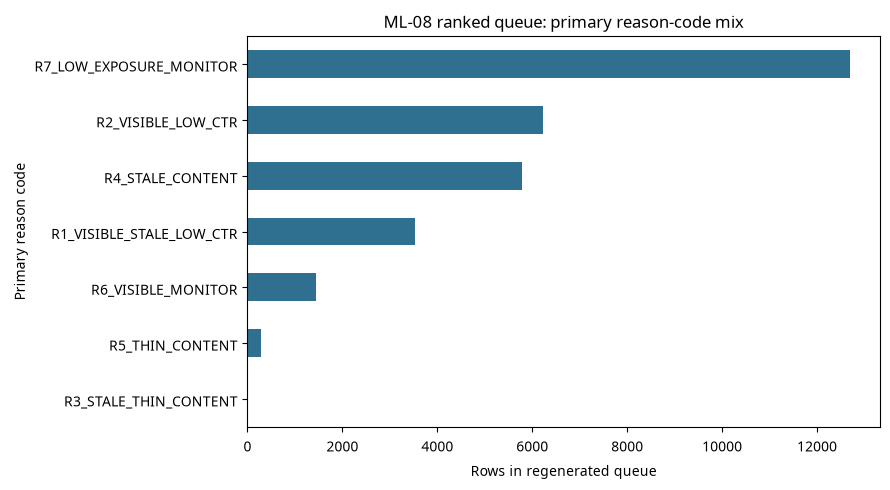

Wrote: /home/ubuntu/flyrank-ml-internship-starter/work/outputs/ranked_action_playbook.csv
Wrote: /home/ubuntu/flyrank-ml-internship-starter/work/figures/w07_reason_code_mix.png
Wrote: /home/ubuntu/flyrank-ml-internship-starter/work/outputs/ml08_action_playbook_metrics.json


In [6]:
queue_path = OUT_DIR / 'ranked_action_playbook.csv'
queue.to_csv(queue_path, index=False)

reason_counts = queue['reason_code'].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
reason_counts.plot(kind='barh', ax=ax, color='#2f6f8f')
ax.set_title('ML-08 ranked queue: primary reason-code mix')
ax.set_xlabel('Rows in regenerated queue')
ax.set_ylabel('Primary reason code')
fig.tight_layout()
fig_path = FIG_DIR / 'w07_reason_code_mix.png'
fig.savefig(fig_path, dpi=160, bbox_inches='tight')
plt.show()

receipt = {
    'seed': SEED,
    'rows_scored': int(len(df)),
    'clients': int(df.client_id.nunique()),
    'queue_file': 'work/outputs/ranked_action_playbook.csv',
    'figure_file': 'work/figures/w07_reason_code_mix.png',
    'model': 'LogisticRegression full snapshot for research prioritization only',
    'features': MODEL_FEATURES,
    'forbidden_features': sorted(FORBIDDEN),
    'top10_reason_codes': queue.head(10)['reason_code'].tolist(),
    'reason_code_counts': {str(k): int(v) for k, v in queue['reason_code'].value_counts().items()},
    'intended_use': 'human-reviewed content prioritization; non-production',
    'automation_prohibited': ['publish','delete','redirect','rewrite','mass edit','causal outcome promise'],
}
(OUT_DIR / 'ml08_action_playbook_metrics.json').write_text(json.dumps(receipt, indent=2) + '\n')
print('Wrote:', queue_path)
print('Wrote:', fig_path)
print('Wrote:', OUT_DIR / 'ml08_action_playbook_metrics.json')

## 6. Self-check

- [x] The queue is ranked and every row has one reason code and one bounded action label.
- [x] The archetype-to-action mapping is explicit and includes editor notes.
- [x] Intended use and limits distinguish prioritization from prediction and production automation.
- [x] Human-review rules and a concrete no-go list are stated.
- [x] Cost/value thinking treats exposure and score as screening proxies, not causal upside.
- [x] Monitoring and retrain triggers are operationally light and require investigation before action.
- [x] The queue CSV and reusable reason-code figure are regenerated under `work/outputs/` and `work/figures/`.
- [x] Label-derived and future-window fields are excluded from model features and exports.
